# Data Filtering and Computational Chemistry (5 pts)

**Instructions:**  You are allowed to use any Jupyter Notebooks and/or Gemini to help you do this assignment; however, keep in mind that ***you will not have Gemini on any quizzes or exams (but you will have your lab notebook as these quizzes/exams are open notebook).*** Therefore, you should take the time to try to understand the general syntax while doing these assignments by taking notes in your lab notebooks as you've done previously. All concept check interactive quizzes are ungraded and have unlimited attempts.


:::{admonition} Overview
- Slice subsets of data from NumPy arrays and pandas DataFrames.
- Filter data using Boolean masks and conditional logic.
- Apply simple smoothing techniques (rolling average and convolution).
:::

## YouTube- Python DataFrames
### Start at DataFrame fundamentals (2:05)

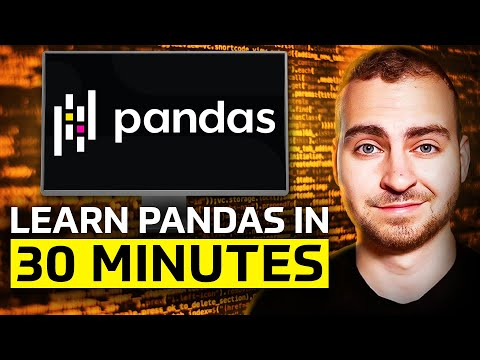

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo("EXIgjIBu4EU",width=640,height=360)

## Import Packages

In [ ]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

%pip install openpyxl --quiet

## Part 1: Review of Data Slicing

In this section, you’ll practice slicing arrays and DataFrames to review indexing techniques.

:::{hint} 🐍 Note
:icon: false
**What is Data Slicing?**

- **Slicing** means selecting a smaller portion of data from a list, NumPy array, or pandas DataFrame.
- **Basic syntax:** `data[start:end]` → includes elements from `start` up to (but not including) `end`.
- You can omit parts:
  - `data[:5]` → from the beginning.
  - `data[5:]` → to the end.
  - `data[:]` → all elements.
- Add a **step** to skip elements: `data[::2]` → every second element.
- Use **negative indices** to count from the end: `data[-3:]` → last three elements.
- In **NumPy arrays**, slicing works the same but supports multiple dimensions, e.g. `arr[0:3, 1:4]`.
- In **pandas**:
  - `.iloc[]` → position-based (row/column numbers).
  - `.loc[]` → label- or condition-based (e.g., `df.loc[df['time'] > 5]`).
- **Remember:** the `end` index is *exclusive*, so `data[0:5]` gives elements `0–4`.

**Quick examples:**
```python
x = [10, 20, 30, 40, 50]
x[1:4]  # → [20, 30, 40]
x[::2]  # → [10, 30, 50]
x[-2:]  # → [40, 50]
```
:::

### 1.1 Array Slicing (1 pt)

In [2]:
# Create a NumPy array with 101 numbers evenly spaced from 0 to 10
x = np.linspace(0, 10, 101)

# Let's look at it
print(x)

[ 0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3
  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7
  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1
  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5
  5.6  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9
  7.   7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3
  8.4  8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7
  9.8  9.9 10. ]


:::{warning} ✏️ Exercise: Practice Data Slicing
:icon: false
Code the following data slicing filters irrespective of the size of the list:

- The first 10 elements.
- The last 5 elements.
- Every 4 elements.
:::

In [3]:
# Populate the list of an arbitrary number of points (between 10-1000) evenly spaced between 0 and 100
random.seed(42) # Generates the seed of random value (guarantees the same randomly generated number)
x = np.linspace(0,100,np.random.randint(10,1000))

# Get the first 10 elements of list
first_10 = x[:10]

# Get the last 5 elements irrepsective of length of list
last_5 = x[-5:]

# Get every 4th element of list
every_4th = x[::4]

print("First 10:", first_10)
print("Last 5:", last_5)
print("Every 5th:", every_4th)

First 10: [0.         0.19723866 0.39447732 0.59171598 0.78895464 0.98619329
 1.18343195 1.38067061 1.57790927 1.77514793]
Last 5: [ 99.21104536  99.40828402  99.60552268  99.80276134 100.        ]
Every 5th: [ 0.          0.78895464  1.57790927  2.36686391  3.15581854  3.94477318
  4.73372781  5.52268245  6.31163708  7.10059172  7.88954635  8.67850099
  9.46745562 10.25641026 11.04536489 11.83431953 12.62327416 13.4122288
 14.20118343 14.99013807 15.7790927  16.56804734 17.35700197 18.14595661
 18.93491124 19.72386588 20.51282051 21.30177515 22.09072978 22.87968442
 23.66863905 24.45759369 25.24654832 26.03550296 26.82445759 27.61341223
 28.40236686 29.1913215  29.98027613 30.76923077 31.5581854  32.34714004
 33.13609467 33.92504931 34.71400394 35.50295858 36.29191321 37.08086785
 37.86982249 38.65877712 39.44773176 40.23668639 41.02564103 41.81459566
 42.6035503  43.39250493 44.18145957 44.9704142  45.75936884 46.54832347
 47.33727811 48.12623274 48.91518738 49.70414201 50.49309665 5

### 1.2 DataFrame Slicing

You purchased a "frictionless" pendulum from the internet, you try it out, but something doesn't seem right. So you plot its motion over 10 oscillations using a camera, and some image recognition software. The result is a little noisy:

<div>
  <center> <img width="500" src="https://github.com/act-cms/adiabatic-expansion-data-analysis/blob/main/01_pre-lab-activity/Figures/PreLab_Pendulum.png?raw=True"> </center>
</div>

:::{warning} ✏️ Exercise: Proving Your Case (2 pts)
:icon: false
You are writing an email to their customer service department and you need proof that your "frictionless pendulum" is losing amplitude! To do this, you will need to do the following:

- Filter the DataFrame in three sections:
  - The first oscillation (0–2 seconds).
  - The fifth oscillation (10–12 seconds).
  - The last oscillation (18–20 seconds).
- Calculate the mean and standard deviation of each section.
- Create an errorbar plot of the filtered data for the three sets.
:::

:::{hint} 🐍 Filtering Data with Conditions in pandas
:icon: false
In **pandas**, you can filter rows by applying **logical conditions** to your DataFrame columns. This returns only the rows that meet those conditions.

**Basic Concept**

A condition such as `df['signal'] > 0` produces a **Series** of `True`/`False` values — one for each row. You can use that Series inside square brackets to select the matching rows:

```python
df_filtered = df[df['signal'] > 0]
```

**Combining Multiple Conditions:**

- Use `&` for AND.
- Use `|` for OR.
- Always wrap each condition in parentheses.

```python
df_filtered = df[(df['signal'] < 0) & (df['time'] > 8)]
```

**Convenient Methods:**

- `df['time'].between(2, 8)` selects rows where time is between 2 and 8.
- `df['category'].isin(['A', 'B'])` selects rows matching specific categories.
:::

In [4]:
# View the sample data for this plot
pos_df=pd.read_excel('Sample-Data/PreLab_SampleData.xlsx',sheet_name='Sheet1',index_col=0)
pos_df

,time,position
0,0.00,0.100751
1,0.02,0.150210
2,0.04,0.227135
3,0.06,0.659826
4,0.08,0.772896
...,...,...
996,19.92,-0.846508
997,19.94,-0.615840
998,19.96,-0.438908
999,19.98,0.076118


In [5]:
# Code the correct logical condition to filter all time measurements under 2 seconds inclusive
first_osc = pos_df.loc[pos_df['time'] <= 2]
first_osc

,time,position
0,0.00,0.100751
1,0.02,0.150210
2,0.04,0.227135
3,0.06,0.659826
4,0.08,0.772896
...,...,...
96,1.92,-0.816450
97,1.94,-0.442799
98,1.96,-0.200764
99,1.98,-0.281744


In [6]:
# Code the correct logical condition to filter all time measurements between 10-12 seconds inclusive
fifth_osc = pos_df[pos_df['time'].between(10,12)]
fifth_osc

,time,position
500,10.00,-0.178340
501,10.02,0.405070
502,10.04,0.599930
503,10.06,0.460348
504,10.08,1.061895
...,...,...
596,11.92,-0.270964
597,11.94,-0.444278
598,11.96,-0.337534
599,11.98,-0.186266


:::{admonition} Note to Instructor
:class:dropdown

```python
pos_df[(pos_df['time']>=10) & (pos_df['time']<=12)]
```

is an alternative way to use the conditions to select the same time window.
:::

In [7]:
# Code the correct logical condition to filter all time measurements between 18-20 seconds inclusive
last_osc = pos_df.loc[pos_df['time'] >= 18]
last_osc

,time,position
900,18.00,0.349740
901,18.02,0.252624
902,18.04,0.470603
903,18.06,0.659044
904,18.08,0.571604
...,...,...
996,19.92,-0.846508
997,19.94,-0.615840
998,19.96,-0.438908
999,19.98,0.076118


In [8]:
# Calculate the mean and standard deviation of each oscillation
first_mean=first_osc['position'].mean()
first_err=first_osc['position'].std(ddof=1)

fifth_mean=fifth_osc['position'].mean()
fifth_err=fifth_osc['position'].std(ddof=1)

last_mean=last_osc['position'].mean()
last_err=last_osc['position'].std(ddof=1)

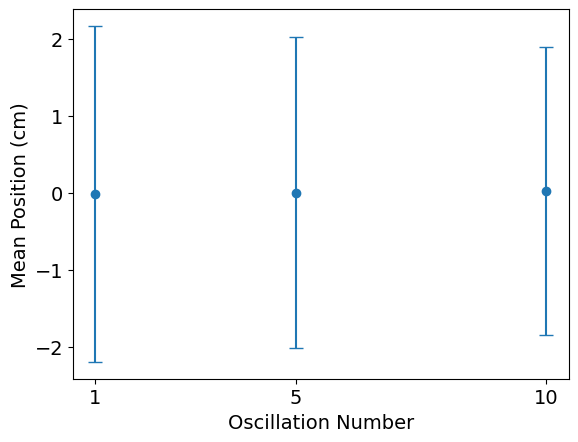

In [9]:
# Create an errorbar plot
oscillation_numbers = [1, 5, 10] # Representing the 1st, 5th, and 10th oscillations
means = [first_mean, fifth_mean, last_mean]
errors = [first_err, fifth_err, last_err]

# Create the errorbar plot for the oscillation data
plt.errorbar(oscillation_numbers, means, yerr=errors, fmt='o', capsize=5)
plt.xlabel("Oscillation Number")
plt.ylabel("Mean Position (cm)")
plt.xticks(oscillation_numbers)
plt.show()

:::{danger} ❓ Question 1
:icon: false
Based on your errorbar plot, do you have a convincing argument against the "frictionless" pendulum?
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> <span style="color:red;">This is a conclusive argument since the standard deviation, which effectively represents the amplitude in this example, decreases as a function of time. This can be seen as the appropriate y error bars.</span>
::::::

:::{danger} ❓ Question 2
:icon: false
What other aspects of this pendulum data can be filtered to provide further analysis?
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> <span style="color:red;">The other two second intervals can be filtered to create a clearer visual of the decreasing amplitude based on the decreasing standard deviation. A plot of the standard deviation as a function of time may also work.</span>
::::::


### 1.3 Moving averages


:::{hint}🐍 What is a moving average?
:icon:false

A moving average calculates the average over a specified range and then propagates that average as it increases in index.
:::

In [10]:
# Run the code below to understand rolling averages
x = pd.DataFrame([0,0,0,1,1,1,2,2,2])
y = x.rolling(3).mean()
y

,0
0,NaN
1,NaN
2,0.000000
3,0.333333
4,0.666667
5,1.000000
6,1.333333
7,1.666667
8,2.000000


:::{danger} ❓ Question 3
:icon: false
What does the code in the cell above do? What is the output and what does it mean?
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
To record your response, double click the cell and type your answer after the `>` below!

> <span style="color:red;">A rolling average (or moving average) smooths out fluctuations in data by taking the average of a fixed number of consecutive data points as the window “rolls” forward through the dataset. For each new position of the window, the oldest value is dropped, and the newest value is added, producing a sequence of averaged values that reveal trends more clearly by reducing noise.</span>
> 
> <span style="color:red;">This particular rolling average rolls every 3 consecutive data points and computes the average. Because the first two points do not have three preceding points, the values are reported as Not-a-Number (or NaN).</span>


:::{warning} ✏️ Exercise: Moving/Rolling Averages (1 pt)
:icon: false
Would a moving average help your case? Try calculating a moving (or rolling) average of 250 points of the position DataFrame (pos_df).
:::

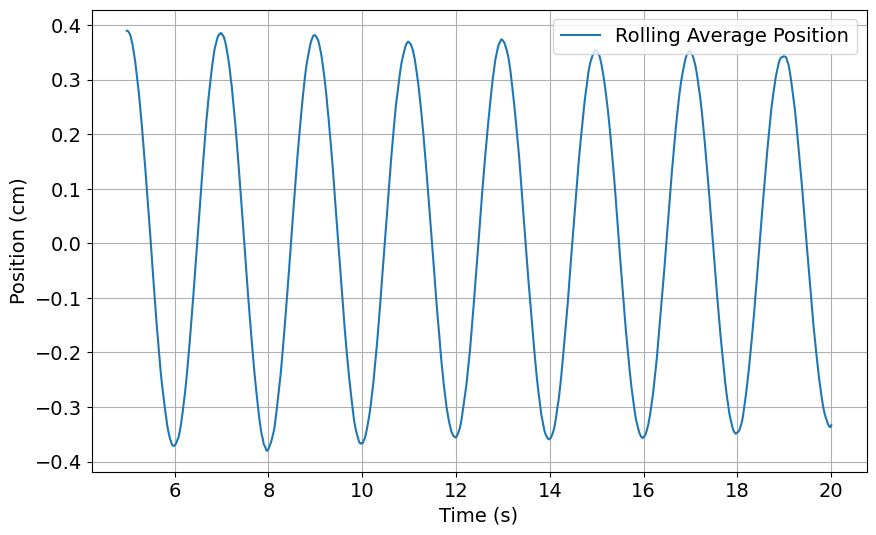

In [11]:
# Calculate the rolling average of pos_df['position']

rolling_avg_position = pos_df['position'].rolling(250).mean()

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(pos_df['time'], rolling_avg_position, label='Rolling Average Position')
plt.xlabel("Time (s)")
plt.ylabel("Position (cm)")
plt.legend()
plt.grid(True)
plt.show()

## Part 2: Calculating thermodynamic values using computational chemistry

In physical chemistry, we often want to connect **molecular structure** with **observable properties** like reaction energies, spectra, or heat capacities. Electronic structure programs such as **ORCA**, **Gaussian**, or **PSI4** do this by numerically solving the **Schrödinger equation** for molecules.

- **Inputs:**  
  - Atom types
  - XYZ coordinates
  - choice of quantum mechanical method (e.g., Hartree–Fock, DFT)
  - basis set (e.g., cc-pVTZ, def2-TZVP).

- **Outputs:**  
  - Optimized molecular geometries  
  - Electronic energies  
  - Molecular orbitals  
  - Vibrational frequencies and thermodynamic properties

The program uses quantum mechanics to determine the electronic energy and force constants of a molecule. From the force constants (via vibrational frequencies), we apply **statistical thermodynamics** to predict macroscopic properties like $C_p$, $C_v$, $\Delta H$, $\Delta S$, and $\Delta G$.  


In [ ]:
import psi4
import os
import sys
import numpy as np
import multiprocessing
import time

# Start the run
start_time = time.time()

# Set the geometry for Ar
mol_Ar = psi4.geometry("""
0 1
Ar 0.0 0.0 0.0
""")
psi4.core.set_output_file('optfreq_output_Ar.out', False)
psi4.frequency('pbe0/cc-pvtz', molecule=mol_Ar, return_wfn=True) # Calculate the thermo properties at the PBE0/cc-pVTZ level of theory

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Calculation Time for Ar: {elapsed_time} seconds")

# Repeat for N2
start_time = time.time()

# Set the initial geometry for N2
mol_N2 = psi4.geometry("""
0 1
N 0.0 0.0 -0.549
N 0.0 0.0 0.549
""")
psi4.core.set_output_file('optfreq_output_N2.out', False)

# Run an optimization and frequency calculation (PBE0/cc-pVTZ)
psi4.optimize('pbe0/cc-pvtz', molecule=mol_N2)
psi4.frequency('pbe0/cc-pvtz', molecule=mol_N2, return_wfn=True)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Calculation Time for N2: {elapsed_time} seconds")

:::{warning} ✏️ Exercise: Text extraction (1 pt)
:icon: false
The code below will open the output files you just generated in Python.
Find the phrase <b>Total G, Gibbs energy</b>,
which is the absolute Gibbs energy
(not to be confused with a Gibbs free energy of formation).
:::

In [13]:
with open('Sample-Data/optfreq_output_Ar.out') as f:
  lines = f.readlines()

lines

['\n',
 '         ----------------------------------------------------------\n',
 '                                   FINDIF\n',
 '                     R. A. King and Jonathon Misiewicz\n',
 '         ----------------------------------------------------------\n',
 '\n',
 '  Using finite-differences of gradients to determine vibrational frequencies and \n',
 '  normal modes. Resulting frequencies are only valid at stationary points.\n',
 '    Generating geometries for use with 3-point formula.\n',
 '    Displacement size will be 5.00e-03.\n',
 '    Number of atoms is 1.\n',
 '    Number of irreps is 8.\n',
 '    Number of SALCs is 0.\n',
 '    Translations projected? 1. Rotations projected? 0.\n',
 '    Index of SALCs per irrep:\n',
 '      1 : \n',
 '      2 : \n',
 '      3 : \n',
 '      4 : \n',
 '      5 : \n',
 '      6 : \n',
 '      7 : \n',
 '      8 : \n',
 '    Number of SALCs per irrep:\n',
 '      Irrep 1: 0\n',
 '      Irrep 2: 0\n',
 '      Irrep 3: 0\n',
 '      Irrep 4:

In [14]:
with open('Sample-Data/optfreq_output_N2.out') as f2:
  lines2 = f2.readlines()

lines2

['\n',
 'Scratch directory: /tmp/\n',
 'gradient() will perform analytic gradient computation.\n',
 '   => Libint2 <=\n',
 '\n',
 '    Primary   basis highest AM E, G, H:  6, 6, 3\n',
 '    Auxiliary basis highest AM E, G, H:  7, 7, 4\n',
 '    Onebody   basis highest AM E, G, H:  -, -, -\n',
 '    Solid Harmonics ordering:            Gaussian\n',
 '\n',
 '*** tstart() called on 4f125c5b2ebd\n',
 '*** at Fri Aug  1 19:45:25 2025\n',
 '\n',
 '   => Loading Basis Set <=\n',
 '\n',
 '    Name: CC-PVTZ\n',
 '    Role: ORBITAL\n',
 '    Keyword: BASIS\n',
 '    atoms 1-2 entry N          line   224 file /usr/local/envs/psi4_env/share/psi4/basis/cc-pvtz.gbs \n',
 '\n',
 '\n',
 '         ---------------------------------------------------------\n',
 '                                   SCF\n',
 '               by Justin Turney, Rob Parrish, Andy Simmonett\n',
 '                          and Daniel G. A. Smith\n',
 '                              RKS Reference\n',
 '                        1 Thr

In [ ]:
# A blank cell if you decide to use Python to extract the text from these files





:::{danger} ❓ Question 4
:icon: false
Search through the output files and report the **Total Energy** for $Ar$ and $N_2$, respectively, in the answer block below. Comment on how you did this.

- Did you use a text search function/command (CTRL+F, grep, regular expressions, etc.)?
- Did you manually search for it?
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> <span style="color:red;">Ar = -527.39640573 Eh, N2 = -109.45421306 Eh (note some of the decimal places will be different based on SCF convergence criteria and numerical precision)</span>
>
> <span style="color:red;">For these files, a simple looking through the file or using CTRL+F will suffice. In the main module, there are a few hundred text files that will require using a loop to efficiently extract all the relevant information. People familiar with bash may opt to use <code>grep</code> to find the phrase.</span>
:::
:::

:::{danger} ❓ Question 5
:icon: false
What coding technique(s) can assist with text extraction if we are dealing with hundreds of text files?
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> <span style="color:red;">Looping structures (for loops) involving getting regular expressions (grep).</span>
::::::

:::{hint}🐍 Note
:icon:false

Download the output files (<strong>optfreq_output_Ar.out</strong>,
<strong>optfreq_output_N2.out</strong>) as you will need them in the next module.

The sample outputs used here will also be available in the next module.
:::